## Student's t-Distribution Hypothesis t Test, P value and Conf. Interval

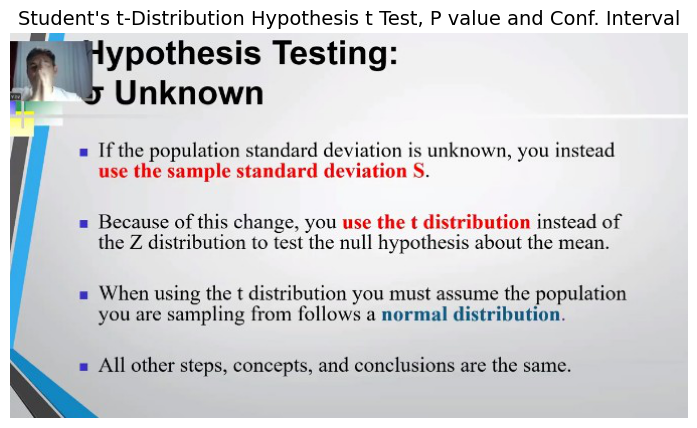

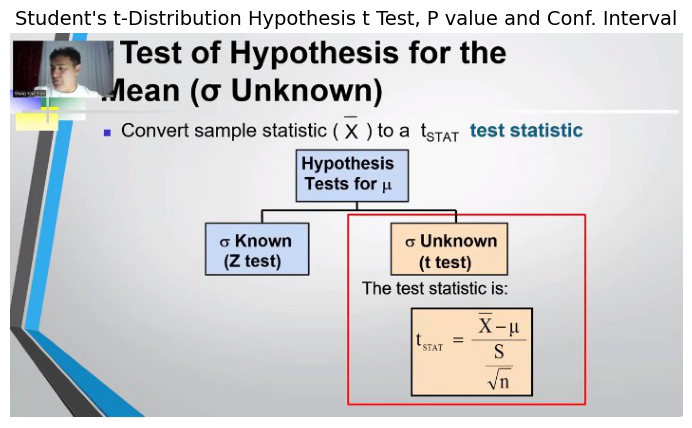

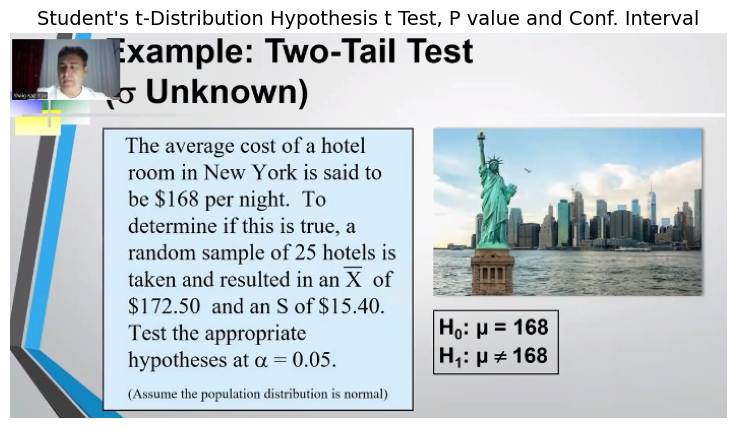

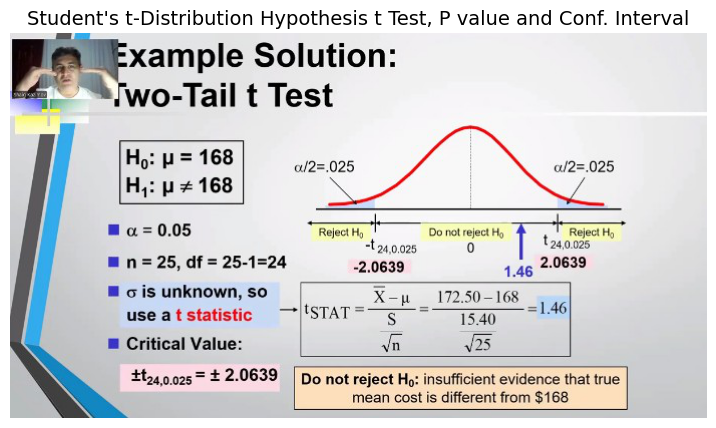

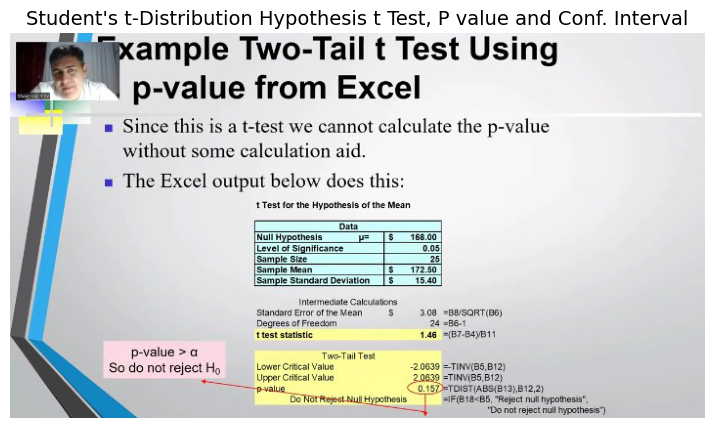

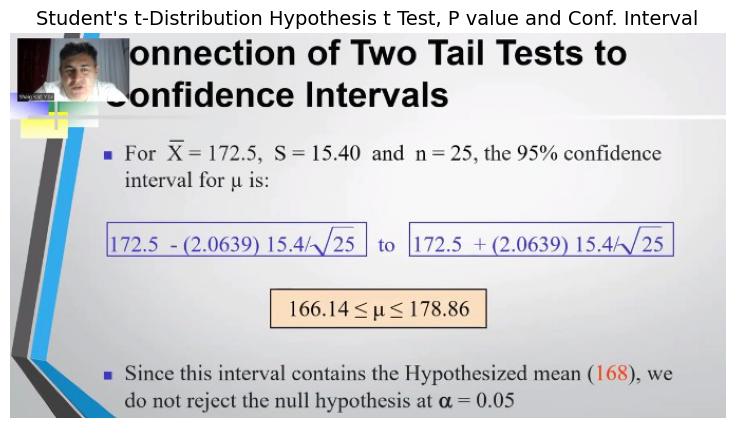

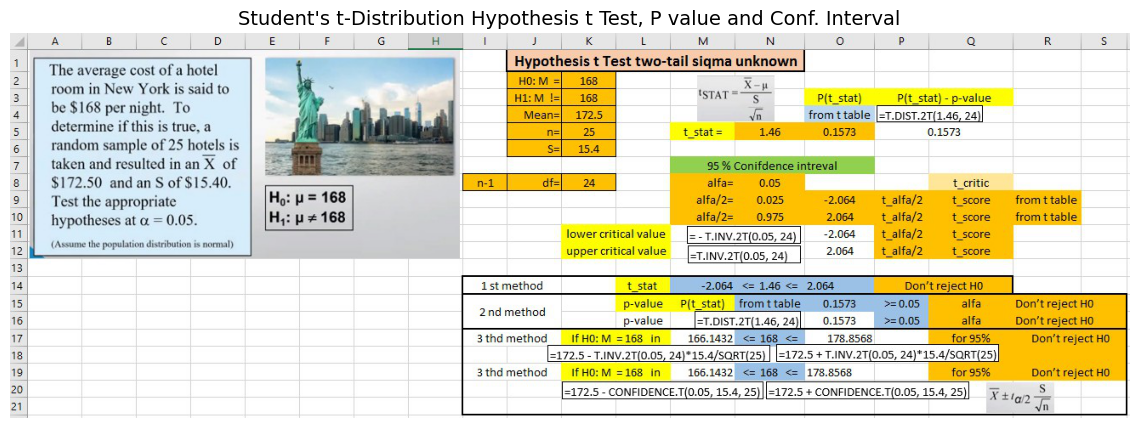

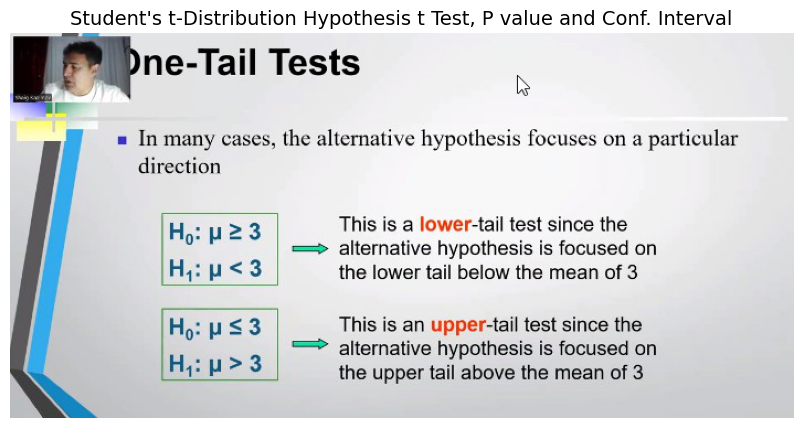

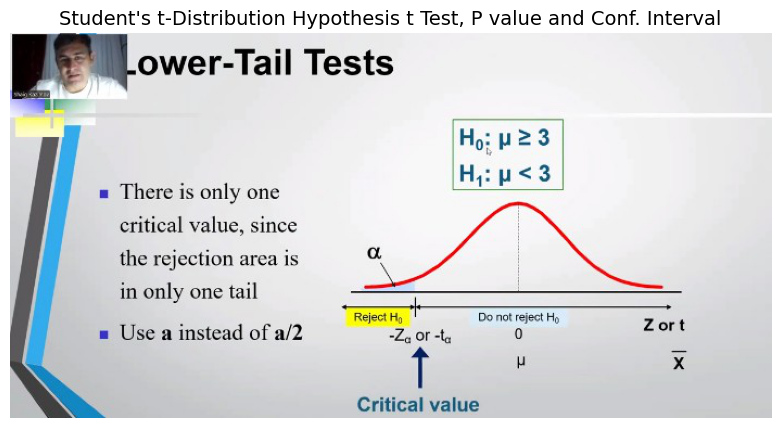

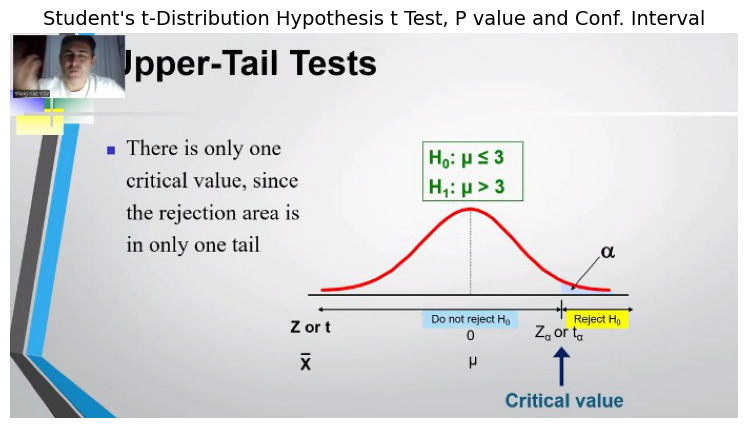

In [24]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Excel\Handex Excel\Statistics\Season_2\Telim_10\Pictures\Distribution_5_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 11):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for image in image_list:
    plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü
    plt.title("Student's t-Distribution Hypothesis t Test, P value and Conf. Interval", size=14)
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

## 🔬 T-Test ilə Hipotez Yoxlaması: T-Stat, P-value və Güvən Intervalı


### ✅ 1. **T-statistic və T\_critical dəyərləri ilə müqayisə**

In [12]:
import scipy.stats as stats
import math

# Verilənlər
mu = 168
sample_mean = 172.5
s = 15.4
n = 25
alpha = 0.05

# T-statistic
SE = s / math.sqrt(n)
t_stat = (sample_mean - mu) / SE

# T-critical (iki tərəfli test üçün)
df = n - 1
t_critical = stats.t.ppf(1 - alpha/2, df)

print(f"T-statistic: {t_stat:.3f}")
print(f"T-critical: ±{t_critical:.3f}")

# Qərar
if abs(t_stat) > t_critical:
    print("🔴 H0 rədd olunur.")
else:
    print("🟢 H0 rədd olunmur.")


T-statistic: 1.461
T-critical: ±2.064
🟢 H0 rədd olunmur.


### ✅ 2. **P-value hesablanması və α ilə müqayisəsi**

In [13]:
# P-value (iki tərəfli test üçün)
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("🔴 P-value < 0.05 → H0 rədd olunur.")
else:
    print("🟢 P-value ≥ 0.05 → H0 rədd olunmur.")


P-value: 0.1570
🟢 P-value ≥ 0.05 → H0 rədd olunmur.


### ✅ 3. **Güvən intervalı (Confidence Interval)**

In [18]:
# 95% Güvən intervalı
df = n - 1
t_critical = stats.t.ppf(1 - alpha/2, df)
SE = s / math.sqrt(n)
margin_error = t_critical * SE

CI_lower = sample_mean - margin_error
CI_upper = sample_mean + margin_error

print(f"95% Confidence Interval: [{CI_lower:.2f}, {CI_upper:.2f}]")

# H0-dakı mu bu aralığa düşürmü?
if mu < CI_lower or mu > CI_upper:
    print("🔴 168 bu aralığa düşmür → H0 rədd olunur.")
else:
    print("🟢 168 bu aralığa düşür → H0 rədd olunmur.")


95% Confidence Interval: [166.14, 178.86]
🟢 168 bu aralığa düşür → H0 rədd olunmur.


## P-value t Score üçün



### ✅ **P-value-nin Riyazi Tərifi**

> P-value, statistik test nəticəsində əldə edilən **test statistikası** (məsələn, \$z\$ və ya \$t\$) əsasında **paylanmanın quyruğunda (tail-də)** qalan **ehtimal sahəsini** təmsil edir.

---

### 🔹 **Riyazi olaraq:**

### ✳️ **Bir tərəfli test üçün:**

Əgər test statistikası \$t\$ kimi dəyərləndirilibsə:

$$
\text{P-value} = P(T \geq t_0) \quad \text{(sağ quyruq)}
$$

və ya

$$
\text{P-value} = P(T \leq t_0) \quad \text{(sol quyruq)}
$$

Bu ehtimallar **sıxlıq funksiyasının inteqralı** ilə tapılır:

$$
\text{P-value} = \int_{t_0}^{\infty} f(t)\,dt \quad \text{(t-paylanma üçün)}
$$

Burada \$f(t)\$ — t-paylanmanın sıxlıq funksiyasıdır və azadlıq dərəcəsi (\$df = n - 1\$) ilə dəyişir.

#### 🔸 **MİSAL (sağ quyruqlu t-test):**

Deyək ki, \$t\_0 = 1.72\$, azadlıq dərəcəsi isə \$df = 15\$.

$$
\text{P-value} = \int_{1.72}^{\infty} f(t; df=15)\,dt \approx 0.053
$$

Bu o deməkdir ki, T = 1.72 və daha böyük nəticə **təxminən 5.3% ehtimalla** baş verə bilər.

#### 🔸 **MİSAL (sol quyruqlu t-test):**

Deyək ki, \$t\_0 = -1.35\$, \$df = 12\$

$$
\text{P-value} = \int_{-\infty}^{-1.35} f(t; df=12)\,dt \approx 0.103
$$

Bu o deməkdir ki, T = -1.35 və daha **kiçik** nəticələr **10.3% ehtimalla** baş verə bilər. Yəni statistik əhəmiyyət yoxdur (\$P > 0.05\$).

---

### ✳️ **İki tərəfli test üçün:**

$$
\text{P-value} = 2 \times P(T \geq |t_0|) = 2 \times \int_{|t_0|}^{\infty} f(t)\,dt
$$

Burada \$f(t)\$ — t-paylanmanın sıxlıq funksiyasıdır, azadlıq dərəcəsindən asılı olaraq dəyişir.

#### 🔸 **MİSAL (iki tərəfli t-test):**

Deyək ki, \$t\_0 = 2.13\$, azadlıq dərəcəsi \$df = 20\$.

$$
\text{P-value} = 2 \times \int_{2.13}^{\infty} f(t; df=20)\,dt \approx 2 \times 0.023 = 0.046
$$

Yəni bu nəticə **statistik əhəmiyyətlidir** (\$\alpha = 0.05\$ üçün), çünki \$P < 0.05\$.

---

### 🔹 **T-paylanma üçün sıxlıq funksiyası (PDF):**

$$
f(t) = \frac{\Gamma\left( \frac{\nu+1}{2} \right)}{\sqrt{\nu\pi}\,\Gamma\left( \frac{\nu}{2} \right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}
$$

Burada:

* \$\nu = df = n - 1\$
* \$\Gamma\$ — Gamma funksiyasıdır

Beləliklə, T-score əsasında P-value:

$$
\text{P-value} = \int_{|t|}^{\infty} f(t)\,dt
$$

Bu inteqral da **əllə hesablamaq çətindir**, ona görə ya **t-cədvəli**, ya da **statistik proqramlar** (məs., `scipy.stats`) istifadə olunur.

#### 🔸 **MİSAL (T-score ilə):**

Əgər \$t = 2.08\$ və \$df = 10\$, o zaman:

$$
\text{P-value} = 2 \times \int_{2.08}^{\infty} f(t; df=10)\,dt \approx 0.065
$$

Bu nəticə statistik olaraq əhəmiyyətli **olmaya bilər**, çünki \$P > 0.05\$.

